# Contextual Associative Bandits [CAB]

## Part 1: Defining The Inference System

In [1]:
import torch

# Disable gradient calculations globally
torch.set_grad_enabled(False)
# Set so that each particle will only use one thread
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
# set torch print options, including line width
torch.set_printoptions(precision=4, sci_mode=False, linewidth=250)

import numpy as np

import torch.distributions as D
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
from idealobserver import IdealObsPFJCRP
from experiment import (
    ExperimentalEnvCRP,
    IOPFSubjectHistory,
    ExperimentHistory,
    CombinedHistory,
)
from particle import print_particle_params

## Part 1: Defining the experiment

### Define the various contexts that can be encountered

In [3]:
NOISE = 0.02
cov_all = torch.eye(2) * NOISE

loc_c0_s0 = torch.tensor([1.0, 0.0])
loc_c0_s1 = torch.tensor([-1.0, 0.0])

loc_c1_s0 = torch.tensor([0.0, 1.0])
loc_c1_s1 = torch.tensor([0.0, -1.0])

loc_c2_s0 = torch.tensor([0.5, 0.5])
loc_c2_s1 = torch.tensor([-0.5, 0.5])

context_o_params = {
    0: {  # context 0
        0: {"loc": loc_c0_s0, "cov": cov_all},  # state 0
        1: {"loc": loc_c0_s1, "cov": cov_all},  # state 1
    },
    1: {  # context 1
        0: {"loc": loc_c1_s0, "cov": cov_all},  # state 0
        1: {"loc": loc_c1_s1, "cov": cov_all},  # state 1
    },
    2: {  # context 0
        0: {"loc": loc_c0_s0, "cov": cov_all},  # state 0
        1: {"loc": loc_c0_s1, "cov": cov_all},  # state 1
        # 0: {"loc": loc_c2_s0, "cov": cov_all},  # state 0
        # 1: {"loc": loc_c2_s1, "cov": cov_all},  # state 1
    },
}

context_r_params = {
    0: {  # context 0
        0: {"p_rew": torch.tensor([1.0, 0.0, 0.0, 0.0])},  # state 0
        1: {"p_rew": torch.tensor([0.0, 1.0, 0.0, 0.0])},  # state 1
    },
    1: {  # context 1
        0: {"p_rew": torch.tensor([0.0, 0.0, 1.0, 0.0])},  # state 0
        1: {"p_rew": torch.tensor([0.0, 0.0, 0.0, 1.0])},  # state 1
    },
    2: {  # context 1
        0: {"p_rew": torch.tensor([0.0, 0.0, 1.0, 0.0])},  # state 0
        1: {"p_rew": torch.tensor([0.0, 0.0, 0.0, 1.0])},  # state 1
        # 0: {"p_rew": torch.tensor([1.0, 0.0, 0.0, 0.0])},  # state 0
        # 1: {"p_rew": torch.tensor([0.0, 0.0, 1.0, 0.0])},  # state 1
    },
}

In [4]:
env = ExperimentalEnvCRP(
    context_o_params=context_o_params, context_r_params=context_r_params
)

## Part 2: Run Simulation

In [5]:
HYP_JCRP = {
    "gamma": 0.02,
    "alpha": 10,
}
HYP_NIW = {
    "mu0": torch.tensor([0.0, 0.0]),
    "kappa0": 0.05,
    "alpha0": 10.0,
    "beta0": 1.0,
}

HYP_BB = {
    "beta0": torch.tensor([0.25, 0.25, 0.25, 0.25]),
    "rho_c": 0.9,
    "rho_i": 0.1,
}

HYP = {"hyp_jcrp": HYP_JCRP, "hyp_niw": HYP_NIW, "hyp_bb": HYP_BB}

#### Simulation


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.96 -0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.21  0.26  0.25]
Step 2:   	True state: 0, Obs.: [ 1.13 -0.28], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.28  0.23  0.23]
Step 3:   	True state: 1, Obs.: [-0.96  0.16], Action: 1, Reward: 1.0, Action probs.: [ 0.09  0.73  0.07  0.11]
Step 4:   	True state: 0, Obs.: [ 1.06  0.23], Action: 0, Reward: 1.0, Action probs.: [ 0.73  0.10  0.09  0.09]
Step 5:   	True state: 0, Obs.: [ 1.08  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.94  0.02  0.02  0.02]
Step 6:   	True state: 1, Obs.: [-1.07  0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.95  0.01  0.02]
Step 7:   	True state: 1, Obs.: [-0.94 -0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 8:   	True state: 1, Obs.: [-0.95 -0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-0.93 -0.03], Action:

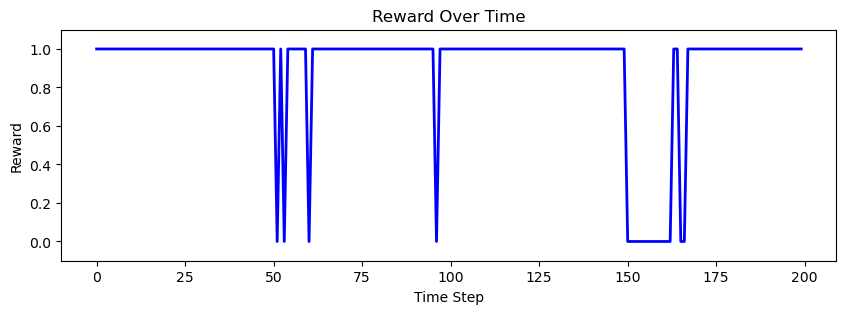


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.86  0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.30  0.21  0.23  0.26]
Step 2:   	True state: 0, Obs.: [ 1.20 -0.00], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.26  0.26  0.24]
Step 3:   	True state: 1, Obs.: [-1.08 -0.19], Action: 0, Reward: 0.0, Action probs.: [ 0.38  0.28  0.04  0.30]
Step 4:   	True state: 0, Obs.: [ 1.09 -0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.35  0.32  0.29  0.04]
Step 5:   	True state: 0, Obs.: [ 0.87  0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.39  0.31  0.29  0.01]
Step 6:   	True state: 0, Obs.: [ 0.93  0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.49  0.05  0.45  0.01]
Step 7:   	True state: 1, Obs.: [-0.88  0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.02  0.46  0.05  0.47]
Step 8:   	True state: 0, Obs.: [ 1.05 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.83  0.09  0.07  0.00]
Step 9:   	True state: 0, Obs.: [ 1.26 -0.03], Action:

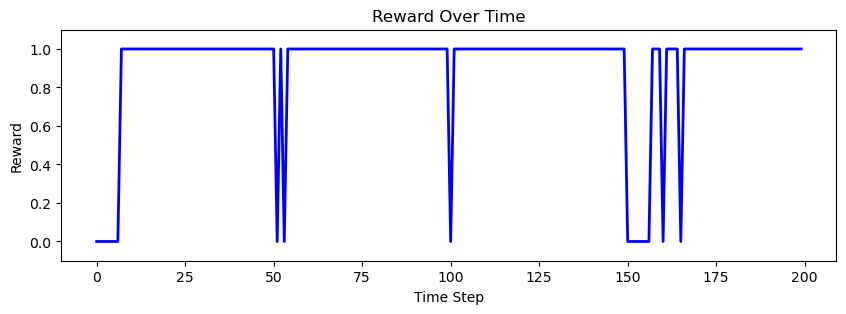


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.13 -0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.29  0.24  0.26  0.21]
Step 2:   	True state: 0, Obs.: [ 0.79 -0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.30  0.30  0.08  0.31]
Step 3:   	True state: 1, Obs.: [-1.22  0.32], Action: 1, Reward: 1.0, Action probs.: [ 0.23  0.27  0.24  0.25]
Step 4:   	True state: 1, Obs.: [-1.04  0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.72  0.10  0.11]
Step 5:   	True state: 0, Obs.: [ 0.97  0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.46  0.05  0.04  0.45]
Step 6:   	True state: 1, Obs.: [-1.14  0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.97  0.01  0.01]
Step 7:   	True state: 1, Obs.: [-1.09  0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 8:   	True state: 1, Obs.: [-0.91 -0.00], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-1.02  0.11], Action:

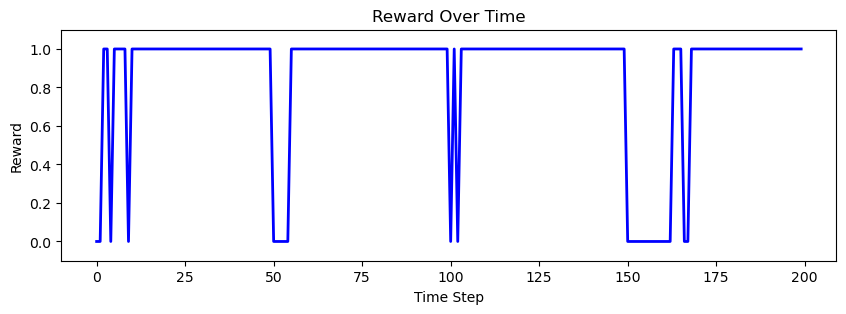


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.99  0.22], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.21  0.25  0.26]
Step 2:   	True state: 1, Obs.: [-0.91  0.21], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.21  0.27  0.24]
Step 3:   	True state: 1, Obs.: [-1.04 -0.02], Action: 3, Reward: 0.0, Action probs.: [ 0.04  0.33  0.28  0.35]
Step 4:   	True state: 0, Obs.: [ 0.96 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.76  0.08  0.06  0.09]
Step 5:   	True state: 0, Obs.: [ 0.82 -0.16], Action: 0, Reward: 1.0, Action probs.: [ 0.97  0.00  0.01  0.01]
Step 6:   	True state: 0, Obs.: [ 0.87 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.00  0.00  0.01]
Step 7:   	True state: 0, Obs.: [ 0.98 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 8:   	True state: 1, Obs.: [-1.12 -0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.47  0.37  0.10]
Step 9:   	True state: 0, Obs.: [ 1.04  0.12], Action:

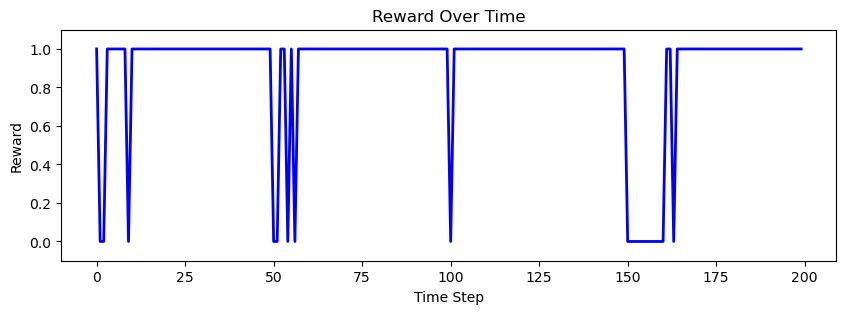


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.97 -0.31], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.26  0.26  0.23]
Step 2:   	True state: 0, Obs.: [ 0.84  0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.20  0.27  0.28]
Step 3:   	True state: 1, Obs.: [-1.10  0.20], Action: 3, Reward: 0.0, Action probs.: [ 0.34  0.32  0.05  0.29]
Step 4:   	True state: 0, Obs.: [ 0.92 -0.01], Action: 1, Reward: 0.0, Action probs.: [ 0.34  0.32  0.03  0.32]
Step 5:   	True state: 1, Obs.: [-0.98 -0.21], Action: 0, Reward: 0.0, Action probs.: [ 0.43  0.49  0.05  0.03]
Step 6:   	True state: 1, Obs.: [-1.06  0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.73  0.08  0.11]
Step 7:   	True state: 0, Obs.: [ 0.90  0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.41  0.05  0.07  0.47]
Step 8:   	True state: 0, Obs.: [ 0.76  0.21], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.01  0.02  0.11]
Step 9:   	True state: 0, Obs.: [ 0.97  0.01], Action:

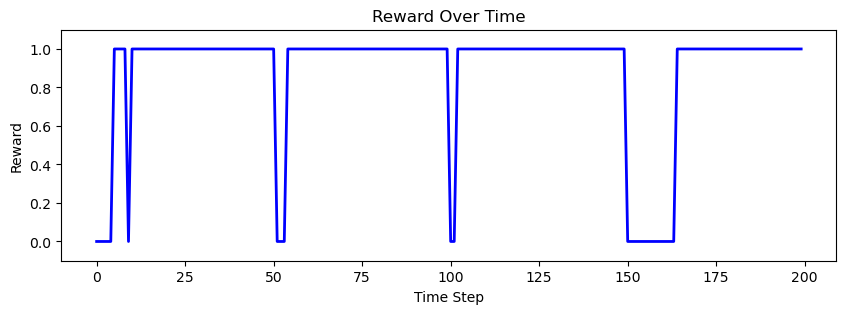


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.02  0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.19  0.27  0.28  0.26]
Step 2:   	True state: 1, Obs.: [-1.19 -0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.23  0.25  0.24  0.29]
Step 3:   	True state: 1, Obs.: [-1.01  0.07], Action: 0, Reward: 0.0, Action probs.: [ 0.07  0.79  0.08  0.06]
Step 4:   	True state: 1, Obs.: [-0.99 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.82  0.09  0.07]
Step 5:   	True state: 1, Obs.: [-0.91 -0.20], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.96  0.02  0.02]
Step 6:   	True state: 0, Obs.: [ 0.96 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.32  0.37  0.28  0.02]
Step 7:   	True state: 0, Obs.: [ 0.78  0.02], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.09  0.06  0.01]
Step 8:   	True state: 0, Obs.: [ 0.79  0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.00  0.00  0.00]
Step 9:   	True state: 0, Obs.: [ 1.05 -0.13], Action:

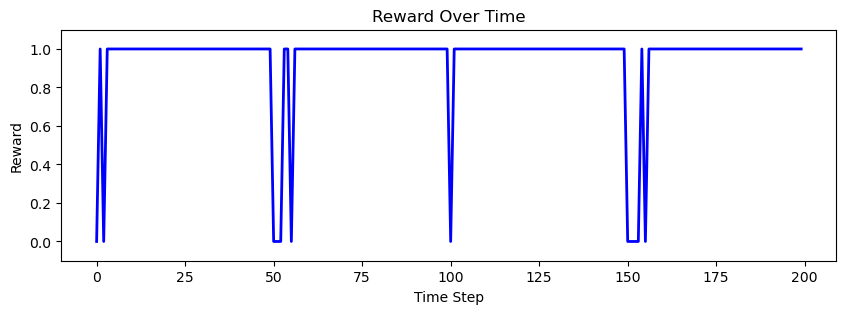


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.88 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.26  0.23  0.23]
Step 2:   	True state: 0, Obs.: [ 1.02  0.26], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.26  0.22  0.28]
Step 3:   	True state: 1, Obs.: [-1.14  0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.09  0.71  0.12  0.07]
Step 4:   	True state: 0, Obs.: [ 1.15  0.00], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.34  0.04  0.32]
Step 5:   	True state: 0, Obs.: [ 0.86  0.19], Action: 1, Reward: 0.0, Action probs.: [ 0.47  0.45  0.03  0.05]
Step 6:   	True state: 0, Obs.: [ 0.87 -0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.77  0.07  0.07  0.09]
Step 7:   	True state: 1, Obs.: [-0.94 -0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.95  0.03  0.02]
Step 8:   	True state: 0, Obs.: [ 0.96 -0.27], Action: 0, Reward: 1.0, Action probs.: [ 0.97  0.02  0.01  0.00]
Step 9:   	True state: 1, Obs.: [-1.03  0.14], Action:

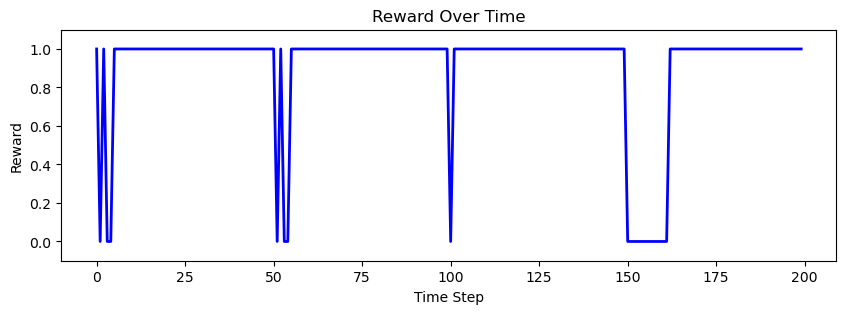


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.13  0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.18  0.30  0.26  0.27]
Step 2:   	True state: 1, Obs.: [-1.06  0.24], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.29  0.22  0.21]
Step 3:   	True state: 0, Obs.: [ 1.01  0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.76  0.07  0.09  0.09]
Step 4:   	True state: 1, Obs.: [-1.00 -0.26], Action: 2, Reward: 0.0, Action probs.: [ 0.31  0.36  0.31  0.02]
Step 5:   	True state: 1, Obs.: [-0.90  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.44  0.46  0.07  0.03]
Step 6:   	True state: 0, Obs.: [ 1.16 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.95  0.02  0.01  0.02]
Step 7:   	True state: 0, Obs.: [ 0.96 -0.12], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 8:   	True state: 0, Obs.: [ 1.05  0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-1.13  0.01], Action:

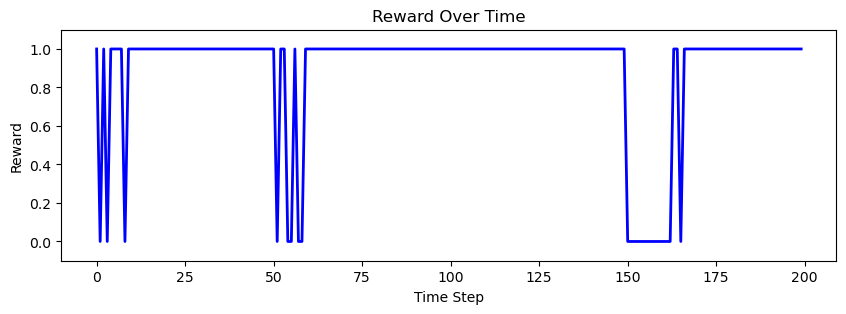


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.69  0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.24  0.25  0.24]
Step 2:   	True state: 1, Obs.: [-1.12  0.26], Action: 1, Reward: 1.0, Action probs.: [ 0.27  0.24  0.29  0.19]
Step 3:   	True state: 0, Obs.: [ 1.19  0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.30  0.35  0.32  0.03]
Step 4:   	True state: 1, Obs.: [-1.12  0.18], Action: 2, Reward: 0.0, Action probs.: [ 0.07  0.75  0.07  0.10]
Step 5:   	True state: 1, Obs.: [-0.78 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.84  0.01  0.07]
Step 6:   	True state: 0, Obs.: [ 0.62  0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.79  0.11  0.09  0.01]
Step 7:   	True state: 0, Obs.: [ 1.10  0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.97  0.01  0.02  0.00]
Step 8:   	True state: 0, Obs.: [ 1.22  0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.00  0.00  0.00]
Step 9:   	True state: 0, Obs.: [ 0.88  0.41], Action:

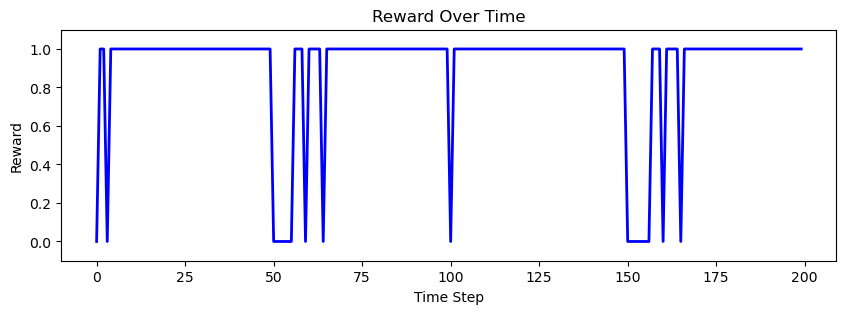


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.86  0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.22  0.27  0.24]
Step 2:   	True state: 0, Obs.: [ 1.14  0.11], Action: 0, Reward: 1.0, Action probs.: [ 0.32  0.30  0.32  0.06]
Step 3:   	True state: 0, Obs.: [ 0.97  0.14], Action: 2, Reward: 0.0, Action probs.: [ 0.72  0.11  0.15  0.02]
Step 4:   	True state: 0, Obs.: [ 0.86  0.29], Action: 0, Reward: 1.0, Action probs.: [ 0.81  0.13  0.03  0.03]
Step 5:   	True state: 0, Obs.: [ 0.94  0.11], Action: 1, Reward: 0.0, Action probs.: [ 0.93  0.03  0.01  0.02]
Step 6:   	True state: 1, Obs.: [-0.96 -0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.31  0.22  0.21  0.26]
Step 7:   	True state: 0, Obs.: [ 1.00  0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.00  0.00  0.01]
Step 8:   	True state: 0, Obs.: [ 0.86  0.05], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-1.08 -0.18], Action:

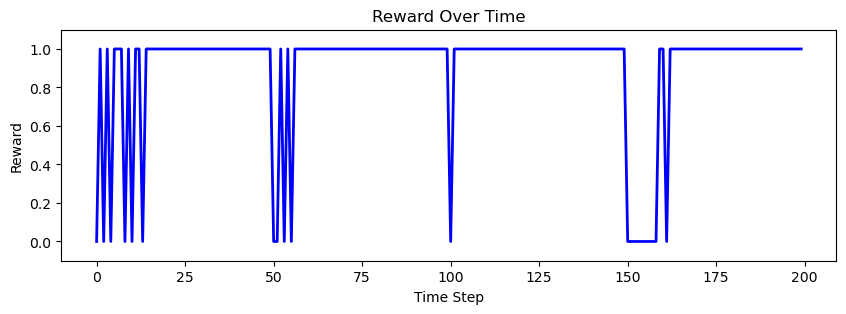


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.28  0.22], Action: 3, Reward: 0.0, Action probs.: [ 0.20  0.27  0.23  0.29]
Step 2:   	True state: 0, Obs.: [ 1.16  0.22], Action: 0, Reward: 1.0, Action probs.: [ 0.29  0.24  0.26  0.22]
Step 3:   	True state: 1, Obs.: [-0.94  0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.35  0.30  0.32  0.04]
Step 4:   	True state: 1, Obs.: [-0.93 -0.04], Action: 0, Reward: 0.0, Action probs.: [ 0.42  0.46  0.05  0.07]
Step 5:   	True state: 1, Obs.: [-1.26  0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.10  0.74  0.09  0.07]
Step 6:   	True state: 1, Obs.: [-0.92  0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.95  0.02  0.02]
Step 7:   	True state: 1, Obs.: [-0.96 -0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 8:   	True state: 1, Obs.: [-0.88 -0.35], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-1.01  0.10], Action:

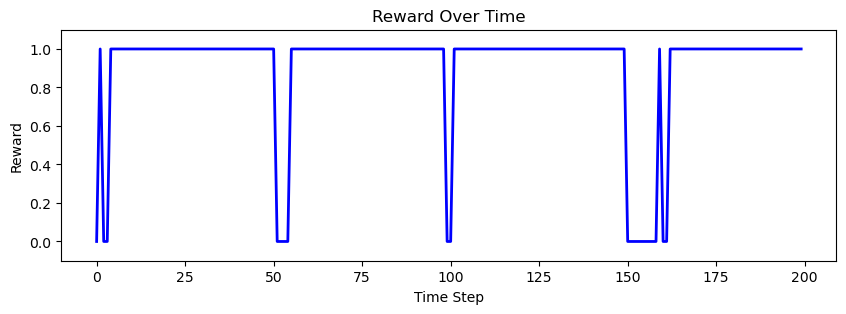


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.95  0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.29  0.21  0.21  0.29]
Step 2:   	True state: 0, Obs.: [ 1.01 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.34  0.30  0.04  0.32]
Step 3:   	True state: 1, Obs.: [-0.85  0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.28  0.26  0.21]
Step 4:   	True state: 1, Obs.: [-0.82 -0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.12  0.75  0.08  0.06]
Step 5:   	True state: 0, Obs.: [ 1.01  0.11], Action: 0, Reward: 1.0, Action probs.: [ 0.80  0.10  0.01  0.10]
Step 6:   	True state: 1, Obs.: [-1.09 -0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.01  0.98  0.01  0.00]
Step 7:   	True state: 1, Obs.: [-0.76  0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.98  0.01  0.00]
Step 8:   	True state: 1, Obs.: [-0.90 -0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-1.15 -0.18], Action:

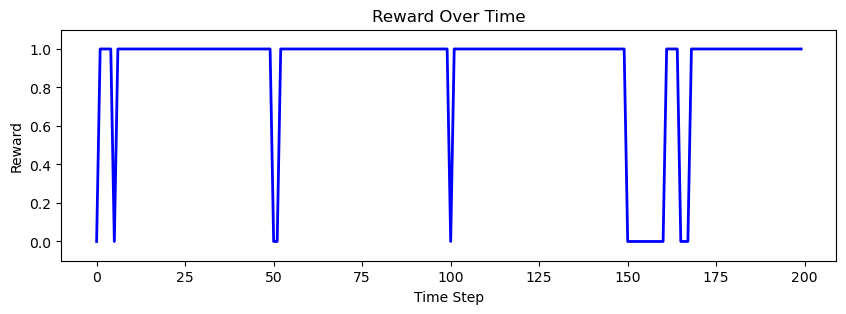


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.13  0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.28  0.24  0.24]
Step 2:   	True state: 0, Obs.: [ 1.04 -0.08], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.27  0.22  0.27]
Step 3:   	True state: 0, Obs.: [ 1.11  0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.36  0.04  0.30  0.31]
Step 4:   	True state: 0, Obs.: [ 0.87 -0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.52  0.04  0.40  0.04]
Step 5:   	True state: 1, Obs.: [-0.95 -0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.03  0.31  0.32  0.34]
Step 6:   	True state: 0, Obs.: [ 1.05 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.01  0.10  0.01]
Step 7:   	True state: 0, Obs.: [ 1.07  0.01], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 8:   	True state: 1, Obs.: [-0.93 -0.07], Action: 0, Reward: 0.0, Action probs.: [ 0.05  0.43  0.05  0.47]
Step 9:   	True state: 0, Obs.: [ 1.13 -0.06], Action:

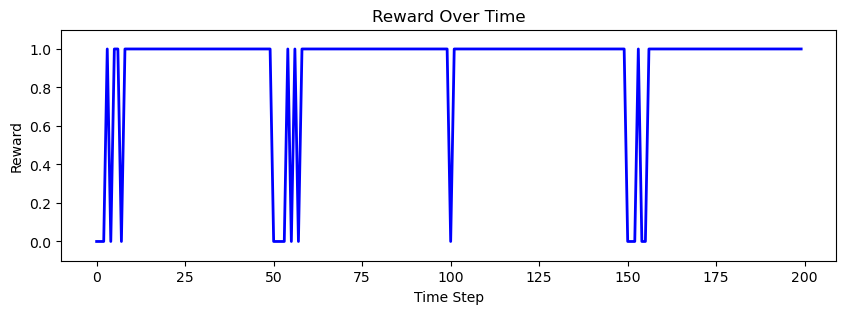


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.97  0.27], Action: 3, Reward: 0.0, Action probs.: [ 0.22  0.26  0.28  0.24]
Step 2:   	True state: 0, Obs.: [ 1.20  0.14], Action: 1, Reward: 0.0, Action probs.: [ 0.22  0.27  0.24  0.28]
Step 3:   	True state: 1, Obs.: [-0.99  0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.27  0.35  0.33  0.05]
Step 4:   	True state: 0, Obs.: [ 1.42  0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.31  0.00  0.33  0.36]
Step 5:   	True state: 0, Obs.: [ 1.09 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.48  0.04  0.45  0.03]
Step 6:   	True state: 0, Obs.: [ 0.95  0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.90  0.01  0.09  0.00]
Step 7:   	True state: 0, Obs.: [ 0.87  0.09], Action: 0, Reward: 1.0, Action probs.: [ 0.94  0.03  0.02  0.01]
Step 8:   	True state: 1, Obs.: [-0.92 -0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.10  0.82  0.08  0.01]
Step 9:   	True state: 1, Obs.: [-1.06 -0.02], Action:

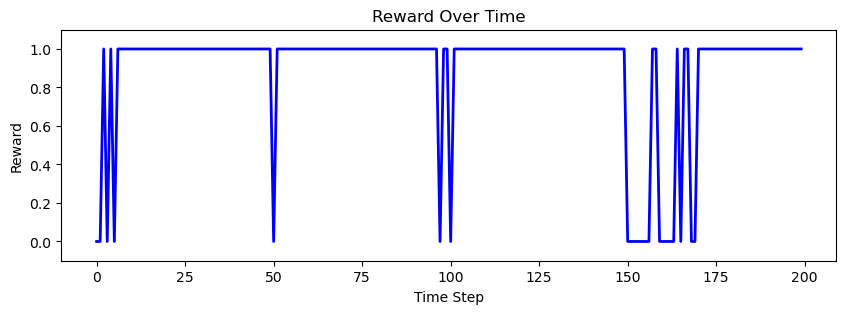


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.94 -0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.28  0.23  0.22]
Step 2:   	True state: 0, Obs.: [ 1.15  0.01], Action: 1, Reward: 0.0, Action probs.: [ 0.29  0.23  0.28  0.20]
Step 3:   	True state: 1, Obs.: [-0.69  0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.79  0.05  0.09]
Step 4:   	True state: 0, Obs.: [ 0.82  0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.34  0.04  0.32  0.30]
Step 5:   	True state: 0, Obs.: [ 1.07 -0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.79  0.01  0.11  0.09]
Step 6:   	True state: 1, Obs.: [-1.06  0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.95  0.02  0.01]
Step 7:   	True state: 0, Obs.: [ 1.04  0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.00  0.01  0.13]
Step 8:   	True state: 0, Obs.: [ 0.89 -0.19], Action: 0, Reward: 1.0, Action probs.: [ 0.98  0.01  0.00  0.02]
Step 9:   	True state: 0, Obs.: [ 0.94  0.05], Action:

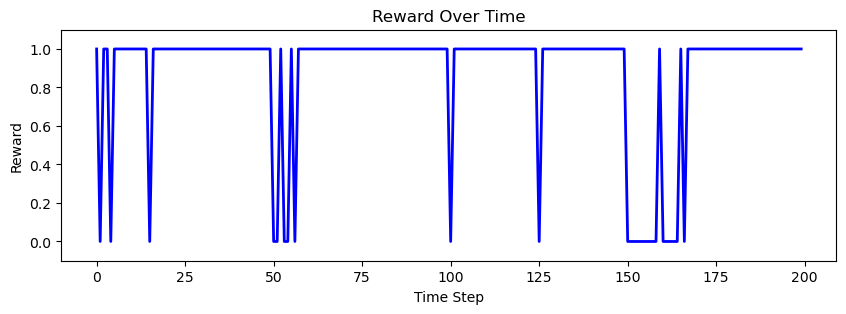


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.97 -0.16], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.23  0.27  0.27]
Step 2:   	True state: 1, Obs.: [-0.88  0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.24  0.28  0.27  0.21]
Step 3:   	True state: 1, Obs.: [-1.30 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.06  0.79  0.06  0.09]
Step 4:   	True state: 1, Obs.: [-0.87 -0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.81  0.01  0.10]
Step 5:   	True state: 1, Obs.: [-1.16  0.16], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.96  0.01  0.01]
Step 6:   	True state: 1, Obs.: [-0.91  0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 7:   	True state: 0, Obs.: [ 0.96  0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.04  0.32  0.35]
Step 8:   	True state: 0, Obs.: [ 1.12 -0.28], Action: 3, Reward: 0.0, Action probs.: [ 0.49  0.02  0.04  0.45]
Step 9:   	True state: 0, Obs.: [ 1.20  0.10], Action:

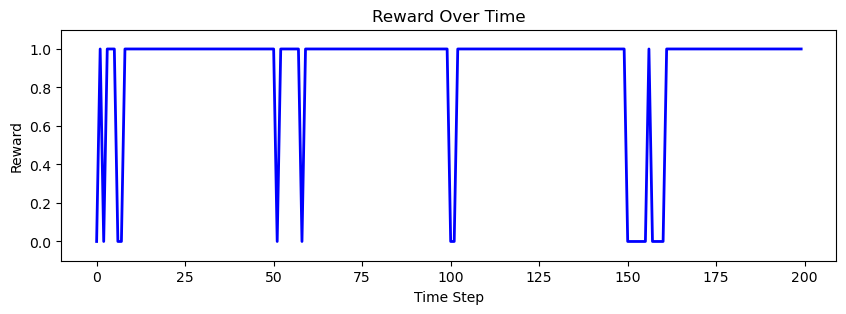


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.01 -0.10], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.21  0.25  0.29]
Step 2:   	True state: 0, Obs.: [ 1.19 -0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.26  0.26  0.22]
Step 3:   	True state: 0, Obs.: [ 1.08 -0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.74  0.08  0.06  0.12]
Step 4:   	True state: 1, Obs.: [-1.18 -0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.04  0.30  0.34  0.32]
Step 5:   	True state: 0, Obs.: [ 1.33 -0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.97  0.02  0.00  0.01]
Step 6:   	True state: 1, Obs.: [-0.91 -0.00], Action: 0, Reward: 0.0, Action probs.: [ 0.08  0.39  0.07  0.45]
Step 7:   	True state: 0, Obs.: [ 0.82  0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.00  0.00  0.01]
Step 8:   	True state: 1, Obs.: [-1.26 -0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.50  0.06  0.44]
Step 9:   	True state: 0, Obs.: [ 0.94  0.02], Action:

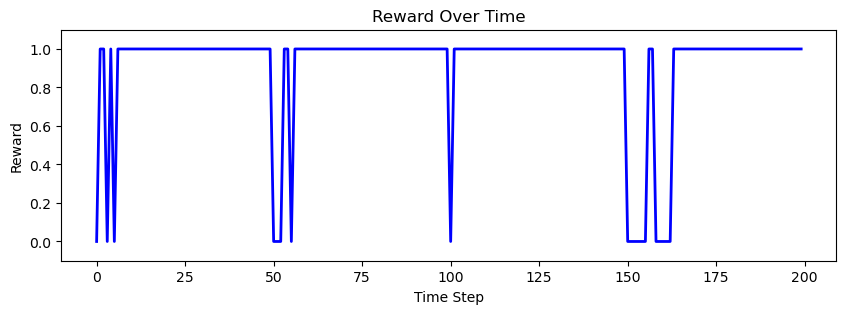


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.95  0.34], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.24  0.27  0.26]
Step 2:   	True state: 1, Obs.: [-1.26 -0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.23  0.27  0.26  0.23]
Step 3:   	True state: 0, Obs.: [ 0.91 -0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.31  0.29  0.05  0.34]
Step 4:   	True state: 1, Obs.: [-1.10  0.31], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.75  0.09  0.10]
Step 5:   	True state: 0, Obs.: [ 0.97 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.79  0.09  0.01  0.10]
Step 6:   	True state: 1, Obs.: [-1.13 -0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.96  0.01  0.01]
Step 7:   	True state: 1, Obs.: [-1.14  0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.99  0.01  0.00]
Step 8:   	True state: 1, Obs.: [-0.84  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 9:   	True state: 0, Obs.: [ 1.07  0.01], Action:

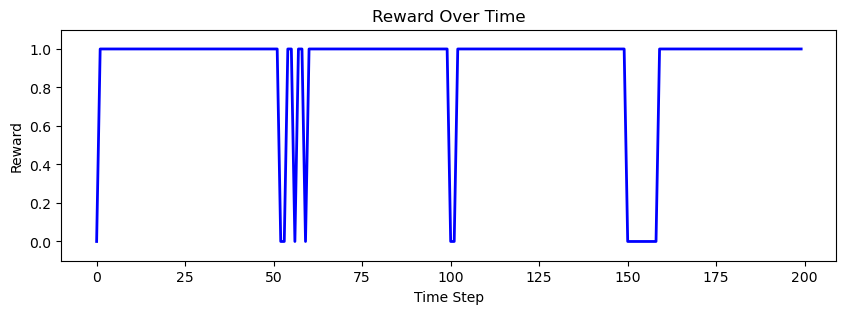


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.96 -0.15], Action: 3, Reward: 0.0, Action probs.: [ 0.19  0.26  0.27  0.28]
Step 2:   	True state: 0, Obs.: [ 1.01 -0.14], Action: 2, Reward: 0.0, Action probs.: [ 0.29  0.33  0.32  0.06]
Step 3:   	True state: 1, Obs.: [-1.06 -0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.23  0.18  0.29  0.30]
Step 4:   	True state: 0, Obs.: [ 0.83  0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.43  0.49  0.03  0.05]
Step 5:   	True state: 0, Obs.: [ 0.99 -0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.90  0.08  0.00  0.02]
Step 6:   	True state: 1, Obs.: [-0.87 -0.16], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.81  0.07  0.08]
Step 7:   	True state: 0, Obs.: [ 0.98  0.00], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.00  0.00  0.00]
Step 8:   	True state: 1, Obs.: [-0.92  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.95  0.02  0.01]
Step 9:   	True state: 1, Obs.: [-1.00 -0.19], Action:

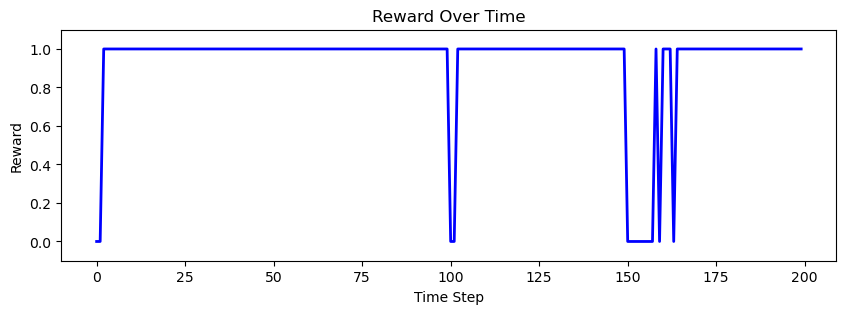


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.19  0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.22  0.26  0.25]
Step 2:   	True state: 1, Obs.: [-0.85  0.10], Action: 3, Reward: 0.0, Action probs.: [ 0.32  0.25  0.22  0.21]
Step 3:   	True state: 0, Obs.: [ 0.93 -0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.70  0.06  0.12  0.12]
Step 4:   	True state: 1, Obs.: [-1.15  0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.34  0.36  0.27  0.02]
Step 5:   	True state: 0, Obs.: [ 1.25  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.95  0.01  0.02  0.02]
Step 6:   	True state: 1, Obs.: [-0.83  0.23], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.85  0.07  0.00]
Step 7:   	True state: 0, Obs.: [ 1.27  0.14], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 8:   	True state: 0, Obs.: [ 0.91 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-0.95  0.20], Action:

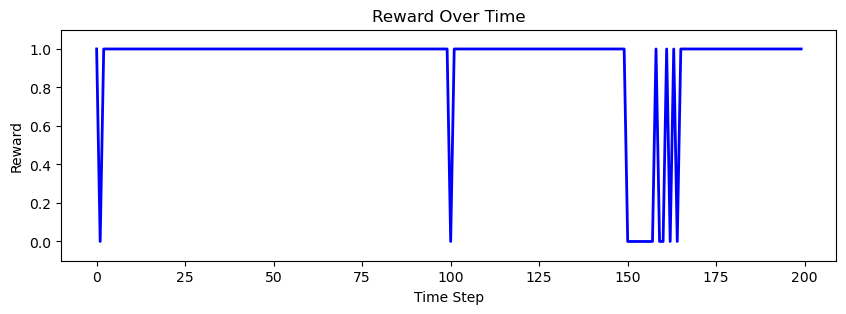


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.31 -0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.24  0.28  0.23]
Step 2:   	True state: 0, Obs.: [ 1.16 -0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.23  0.32  0.23  0.22]
Step 3:   	True state: 1, Obs.: [-1.02 -0.06], Action: 0, Reward: 0.0, Action probs.: [ 0.31  0.38  0.27  0.04]
Step 4:   	True state: 1, Obs.: [-0.89 -0.22], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.46  0.45  0.05]
Step 5:   	True state: 0, Obs.: [ 1.33  0.02], Action: 0, Reward: 1.0, Action probs.: [ 0.30  0.05  0.35  0.29]
Step 6:   	True state: 0, Obs.: [ 1.00  0.16], Action: 0, Reward: 1.0, Action probs.: [ 0.78  0.02  0.11  0.09]
Step 7:   	True state: 0, Obs.: [ 1.03 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.97  0.00  0.02  0.01]
Step 8:   	True state: 1, Obs.: [-1.01  0.00], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.87  0.11  0.01]
Step 9:   	True state: 1, Obs.: [-1.00  0.26], Action:

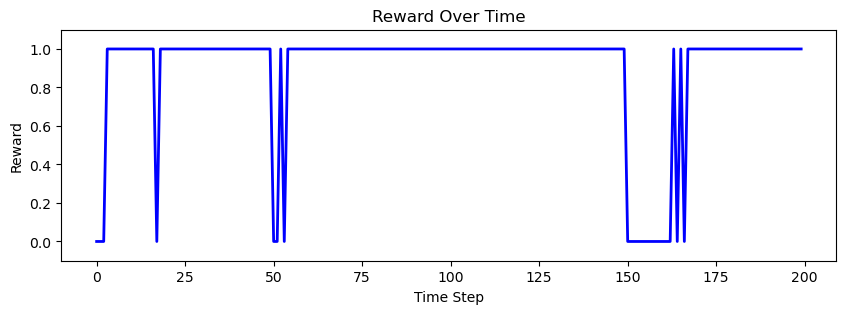


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.69  0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.27  0.23  0.25]
Step 2:   	True state: 1, Obs.: [-0.70  0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.26  0.20  0.24]
Step 3:   	True state: 0, Obs.: [ 0.91  0.22], Action: 0, Reward: 1.0, Action probs.: [ 0.29  0.33  0.04  0.34]
Step 4:   	True state: 0, Obs.: [ 0.99 -0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.80  0.10  0.01  0.09]
Step 5:   	True state: 0, Obs.: [ 1.02 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.98  0.01  0.00  0.01]
Step 6:   	True state: 1, Obs.: [-1.29  0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.32  0.34  0.32  0.03]
Step 7:   	True state: 1, Obs.: [-0.79  0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.05  0.46  0.43  0.07]
Step 8:   	True state: 1, Obs.: [-1.16  0.19], Action: 0, Reward: 0.0, Action probs.: [ 0.09  0.74  0.05  0.11]
Step 9:   	True state: 0, Obs.: [ 1.15  0.06], Action:

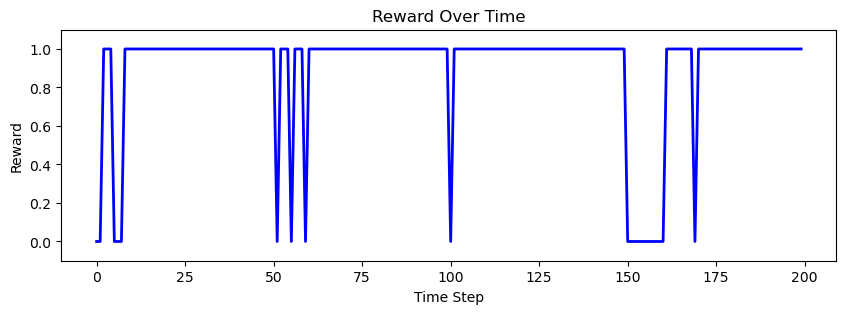


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.95  0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.24  0.26  0.28  0.21]
Step 2:   	True state: 0, Obs.: [ 0.93 -0.18], Action: 1, Reward: 0.0, Action probs.: [ 0.28  0.26  0.25  0.21]
Step 3:   	True state: 1, Obs.: [-0.80 -0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.74  0.11  0.07]
Step 4:   	True state: 0, Obs.: [ 0.89 -0.20], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.05  0.32  0.33]
Step 5:   	True state: 1, Obs.: [-0.91 -0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.96  0.02  0.01]
Step 6:   	True state: 1, Obs.: [-1.01  0.18], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 7:   	True state: 0, Obs.: [ 0.92  0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.47  0.03  0.46  0.03]
Step 8:   	True state: 1, Obs.: [-1.39  0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.99  0.01  0.00]
Step 9:   	True state: 0, Obs.: [ 0.88 -0.27], Action:

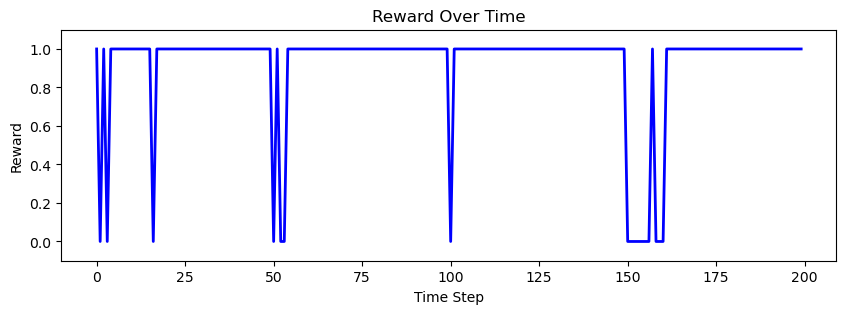


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.09  0.12], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.26  0.27  0.22]
Step 2:   	True state: 1, Obs.: [-0.85 -0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.23  0.22  0.28]
Step 3:   	True state: 1, Obs.: [-0.79 -0.25], Action: 0, Reward: 0.0, Action probs.: [ 0.32  0.33  0.32  0.02]
Step 4:   	True state: 1, Obs.: [-0.78  0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.06  0.40  0.49  0.06]
Step 5:   	True state: 0, Obs.: [ 1.29  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.32  0.32  0.32  0.04]
Step 6:   	True state: 0, Obs.: [ 1.17  0.37], Action: 1, Reward: 0.0, Action probs.: [ 0.46  0.46  0.06  0.03]
Step 7:   	True state: 0, Obs.: [ 1.18 -0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.74  0.08  0.08  0.09]
Step 8:   	True state: 1, Obs.: [-1.08  0.15], Action: 2, Reward: 0.0, Action probs.: [ 0.06  0.74  0.09  0.11]
Step 9:   	True state: 0, Obs.: [ 1.03  0.10], Action:

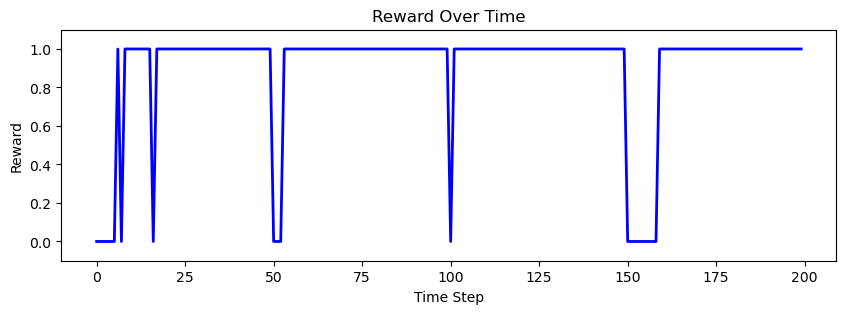


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.13  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.27  0.27  0.24]
Step 2:   	True state: 0, Obs.: [ 1.11  0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.36  0.30  0.06  0.29]
Step 3:   	True state: 0, Obs.: [ 0.86  0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.78  0.07  0.03  0.11]
Step 4:   	True state: 0, Obs.: [ 0.91 -0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.89  0.03  0.04  0.04]
Step 5:   	True state: 1, Obs.: [-0.83  0.10], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.25  0.24  0.27]
Step 6:   	True state: 1, Obs.: [-1.09  0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.02  0.32  0.32  0.34]
Step 7:   	True state: 1, Obs.: [-0.95 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.43  0.04  0.47]
Step 8:   	True state: 0, Obs.: [ 0.79 -0.13], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 9:   	True state: 0, Obs.: [ 1.13  0.04], Action:

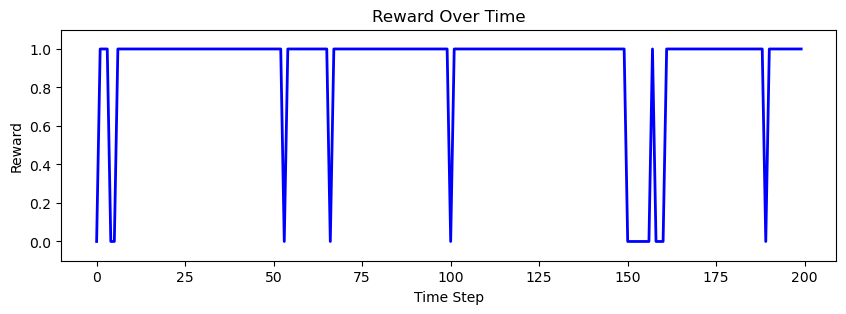


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.84 -0.27], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.23  0.33  0.22]
Step 2:   	True state: 1, Obs.: [-0.95  0.09], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.30  0.10  0.33]
Step 3:   	True state: 1, Obs.: [-1.16  0.12], Action: 0, Reward: 0.0, Action probs.: [ 0.38  0.43  0.12  0.07]
Step 4:   	True state: 0, Obs.: [ 0.88  0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.22  0.24  0.25  0.29]
Step 5:   	True state: 0, Obs.: [ 1.01  0.08], Action: 1, Reward: 0.0, Action probs.: [ 0.73  0.10  0.11  0.07]
Step 6:   	True state: 1, Obs.: [-1.08 -0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.11  0.70  0.10  0.08]
Step 7:   	True state: 0, Obs.: [ 0.79 -0.02], Action: 0, Reward: 1.0, Action probs.: [ 0.81  0.01  0.11  0.06]
Step 8:   	True state: 0, Obs.: [ 1.05  0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.98  0.00  0.01  0.01]
Step 9:   	True state: 1, Obs.: [-1.10 -0.17], Action:

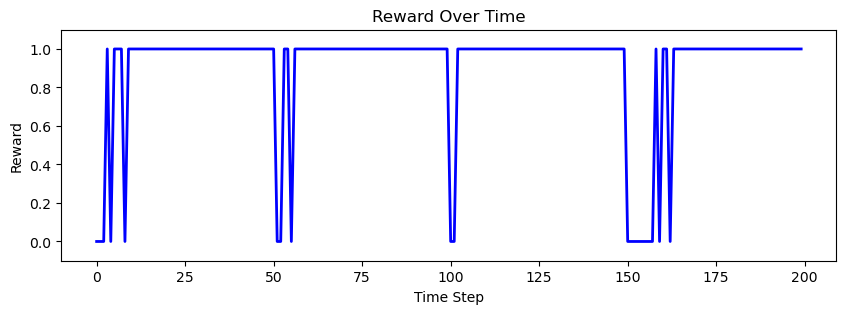


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.08 -0.12], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.22  0.29  0.24]
Step 2:   	True state: 1, Obs.: [-0.98 -0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.05  0.34  0.28  0.33]
Step 3:   	True state: 0, Obs.: [ 0.91 -0.28], Action: 3, Reward: 0.0, Action probs.: [ 0.22  0.28  0.30  0.20]
Step 4:   	True state: 0, Obs.: [ 1.14 -0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.31  0.29  0.36  0.04]
Step 5:   	True state: 0, Obs.: [ 0.93  0.00], Action: 1, Reward: 0.0, Action probs.: [ 0.41  0.49  0.04  0.05]
Step 6:   	True state: 0, Obs.: [ 0.85 -0.21], Action: 0, Reward: 1.0, Action probs.: [ 0.76  0.09  0.06  0.09]
Step 7:   	True state: 1, Obs.: [-1.00 -0.09], Action: 0, Reward: 0.0, Action probs.: [ 0.07  0.40  0.06  0.47]
Step 8:   	True state: 0, Obs.: [ 1.06  0.33], Action: 3, Reward: 0.0, Action probs.: [ 0.96  0.01  0.00  0.02]
Step 9:   	True state: 1, Obs.: [-1.05  0.15], Action:

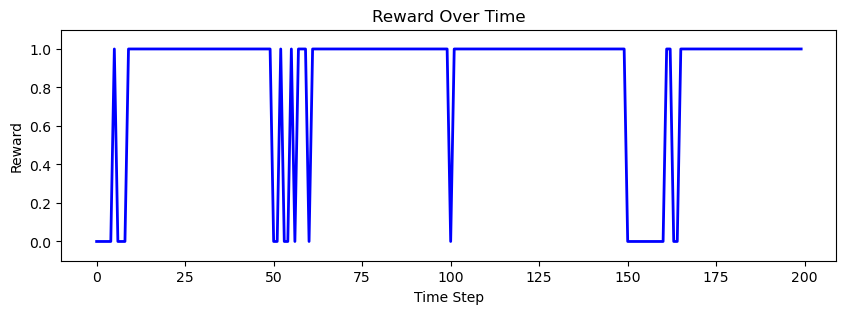


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.86 -0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.24  0.26  0.23]
Step 2:   	True state: 0, Obs.: [ 0.97 -0.09], Action: 1, Reward: 0.0, Action probs.: [ 0.29  0.28  0.05  0.38]
Step 3:   	True state: 0, Obs.: [ 1.15  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.43  0.07  0.04  0.46]
Step 4:   	True state: 0, Obs.: [ 1.12  0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.04  0.02  0.10]
Step 5:   	True state: 1, Obs.: [-1.08 -0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.18  0.21  0.33  0.28]
Step 6:   	True state: 1, Obs.: [-0.78 -0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.31  0.27  0.36  0.06]
Step 7:   	True state: 0, Obs.: [ 1.18  0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.01  0.00  0.00]
Step 8:   	True state: 0, Obs.: [ 1.34 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 9:   	True state: 0, Obs.: [ 0.67 -0.04], Action:

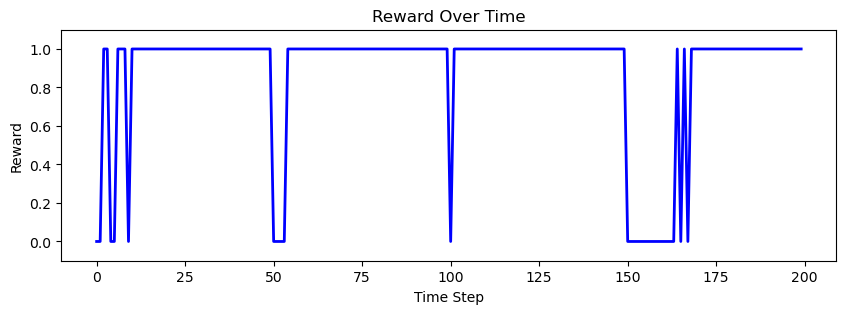


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.27  0.19], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.26  0.23  0.28]
Step 2:   	True state: 1, Obs.: [-0.86 -0.13], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.22  0.24  0.29]
Step 3:   	True state: 0, Obs.: [ 0.83  0.02], Action: 3, Reward: 0.0, Action probs.: [ 0.37  0.28  0.05  0.30]
Step 4:   	True state: 1, Obs.: [-0.99  0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.02  0.36  0.30  0.32]
Step 5:   	True state: 0, Obs.: [ 0.91 -0.02], Action: 0, Reward: 1.0, Action probs.: [ 0.51  0.39  0.05  0.06]
Step 6:   	True state: 1, Obs.: [-0.95 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.39  0.10  0.46]
Step 7:   	True state: 1, Obs.: [-0.98  0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.89  0.01  0.08]
Step 8:   	True state: 0, Obs.: [ 1.07 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.08  0.00  0.01]
Step 9:   	True state: 0, Obs.: [ 0.96 -0.09], Action:

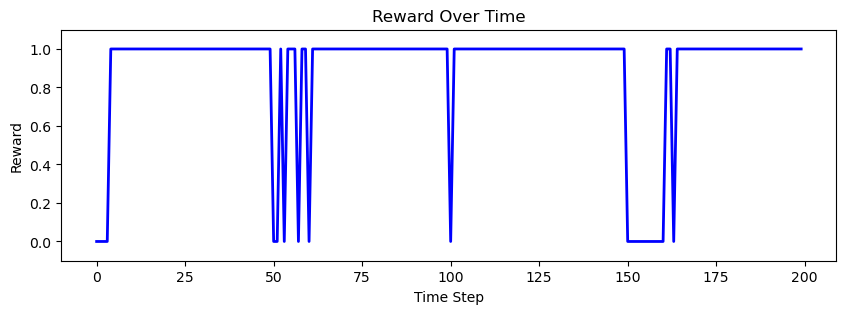


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.16 -0.18], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.23  0.26  0.27]
Step 2:   	True state: 0, Obs.: [ 0.78 -0.31], Action: 1, Reward: 0.0, Action probs.: [ 0.22  0.22  0.31  0.26]
Step 3:   	True state: 0, Obs.: [ 0.94 -0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.31  0.07  0.29  0.33]
Step 4:   	True state: 1, Obs.: [-1.10 -0.03], Action: 0, Reward: 0.0, Action probs.: [ 0.36  0.32  0.30  0.02]
Step 5:   	True state: 1, Obs.: [-0.92  0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.06  0.46  0.43  0.05]
Step 6:   	True state: 1, Obs.: [-1.22  0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.04  0.45  0.52  0.00]
Step 7:   	True state: 1, Obs.: [-0.74 -0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.85  0.07  0.01]
Step 8:   	True state: 0, Obs.: [ 1.07 -0.20], Action: 0, Reward: 1.0, Action probs.: [ 0.80  0.02  0.08  0.11]
Step 9:   	True state: 1, Obs.: [-0.92 -0.16], Action:

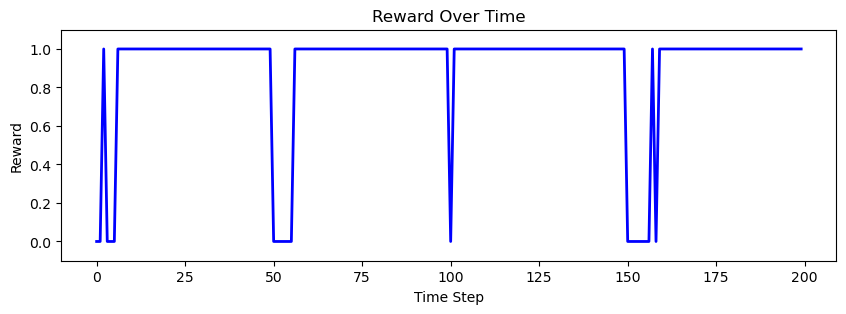


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.05 -0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.30  0.24  0.19  0.28]
Step 2:   	True state: 1, Obs.: [-0.92 -0.20], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.72  0.11  0.09]
Step 3:   	True state: 0, Obs.: [ 0.85  0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.27  0.26  0.21  0.26]
Step 4:   	True state: 1, Obs.: [-1.01  0.10], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.97  0.02  0.01]
Step 5:   	True state: 1, Obs.: [-1.03 -0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.99  0.00  0.00]
Step 6:   	True state: 1, Obs.: [-0.78  0.25], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.99  0.00  0.00]
Step 7:   	True state: 1, Obs.: [-0.91 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.00  1.00  0.00  0.00]
Step 8:   	True state: 0, Obs.: [ 1.00 -0.00], Action: 0, Reward: 1.0, Action probs.: [ 0.35  0.03  0.30  0.33]
Step 9:   	True state: 1, Obs.: [-1.05 -0.23], Action:

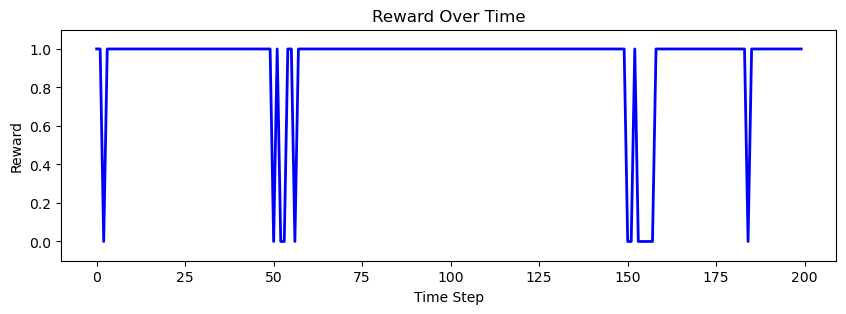


 << Running 50 trials with true context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.98 -0.26], Action: 1, Reward: 1.0, Action probs.: [ 0.21  0.26  0.25  0.28]
Step 2:   	True state: 0, Obs.: [ 0.88 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.27  0.22  0.25]
Step 3:   	True state: 0, Obs.: [ 1.17 -0.10], Action: 3, Reward: 0.0, Action probs.: [ 0.77  0.10  0.04  0.09]
Step 4:   	True state: 0, Obs.: [ 1.22  0.16], Action: 2, Reward: 0.0, Action probs.: [ 0.78  0.11  0.11  0.00]
Step 5:   	True state: 1, Obs.: [-1.09  0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.77  0.08  0.07]
Step 6:   	True state: 0, Obs.: [ 0.80 -0.19], Action: 0, Reward: 1.0, Action probs.: [ 0.92  0.05  0.02  0.01]
Step 7:   	True state: 0, Obs.: [ 1.09  0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.98  0.02  0.00  0.00]
Step 8:   	True state: 0, Obs.: [ 0.80 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 1.00  0.00  0.00  0.00]
Step 9:   	True state: 1, Obs.: [-1.14 -0.18], Action:

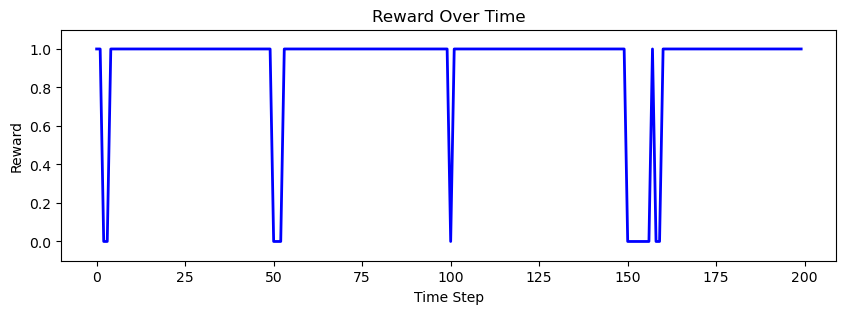

In [6]:
results = []

for i in range(32):

    # Initialize history buffers
    exp_history = ExperimentHistory()
    sub_history = IOPFSubjectHistory()

    # Initialize ensemble
    subject = IdealObsPFJCRP(N=250, hyp_params=HYP, n_workers=8)
    # ensemble = Ensemble(N=1000, hyp_jcrp=HYP_JCRP, hyp_niw=HYP_NIW, hyp_bb=HYP_BB)

    # Run 50 trials in context (c_=0)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c=0,
        print_level=3,
    )
    # Run 50 trials in context (c=1)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c=1,
        print_level=3,
    )

    # Run 50 trials in context (c_=0)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c=0,
        print_level=3,
    )

    # Run 50 trials in context (c_=2)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c=2,
        print_level=3,
    )

    subject.deallocate()

    # Combine histories into single object
    combined_history = CombinedHistory(
        subject_history=sub_history, experiment_history=exp_history
    )

    results.append(combined_history)

    plt.figure(figsize=(10, 3))
    plt.plot(
        combined_history.experiment_history.reward,
        label="Reward",
        color="blue",
        linewidth=2,
    )
    plt.title("Reward Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Reward")
    plt.ylim(-0.1, 1.1)
    plt.show()

In [7]:
# for particle in subject.particles:
#     print(f"\n>> Particle {particle}:\n")
#     print_particle_params(particle)

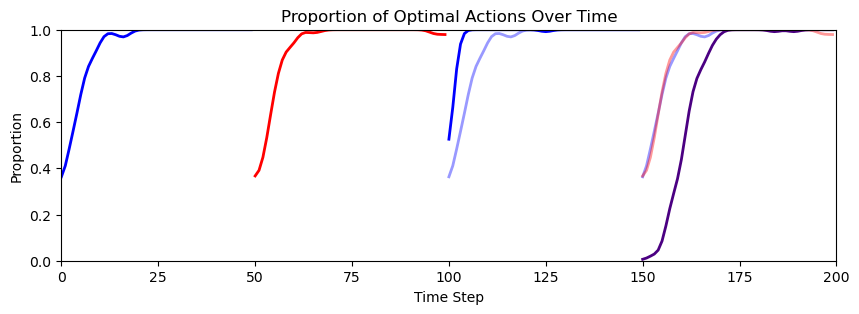

In [8]:
proportion_optimal_mean = np.zeros(200)

chosen = list(range(32))

for j in chosen:

    proportion_optimal_mean += np.array(results[j].experiment_history.reward)

proportion_optimal_mean /= len(chosen)

# gaussian blur with kernel size 5 and sigma 1
from scipy.ndimage import gaussian_filter1d


def smooth(result):
    return gaussian_filter1d(result, sigma=1.5)


task_1 = smooth(proportion_optimal_mean[0:50])
task_1_dur = np.arange(0, 50)
task_2 = smooth(proportion_optimal_mean[50:100])
task_2_dur = np.arange(50, 100)
task_3 = smooth(proportion_optimal_mean[100:150])
task_3_dur = np.arange(100, 150)
task_4 = smooth(proportion_optimal_mean[150:200])
task_4_dur = np.arange(150, 200)


plt.figure(figsize=(10, 3))
# plt.plot(proportion_optimal_mean, label='Proportion Optimal Action', color='blue', linewidth=2)
plt.plot(task_1_dur, task_1, color="blue", linewidth=2, alpha=1.0)
plt.plot(task_2_dur, task_2, color="red", linewidth=2, alpha=1.0)
plt.plot(task_3_dur, task_3, color="blue", linewidth=2, alpha=1.0)
plt.plot(task_4_dur, task_4, color="indigo", linewidth=2, alpha=1.0)
plt.plot(task_3_dur, task_1, color="blue", linewidth=2, alpha=0.4)
plt.plot(task_4_dur, task_1, color="blue", linewidth=2, alpha=0.4)
plt.plot(task_4_dur, task_2, color="red", linewidth=2, alpha=0.4)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, len(proportion_optimal_mean))
# plt.savefig("g_proportion_optimal_3.pdf")
plt.show()

## Part 3: Analysis of Results

#### Sanity check of inferred parameters

### Visualisation of Results

In [9]:
print(type(results[j]))
print(vars(results[j]).keys())
print(vars(results[j].experiment_history).keys())
print(vars(results[j].subject_history).keys())

<class 'experiment.CombinedHistory'>
dict_keys(['experiment_history', 'subject_history'])
dict_keys(['state', 'context_o', 'context_r', 'observation', 'optimal_action', 'action', 'reward'])
dict_keys(['p_action', 'p_state', 'p_jump', 'context_o', 'context_r', 'weights'])


Context History:


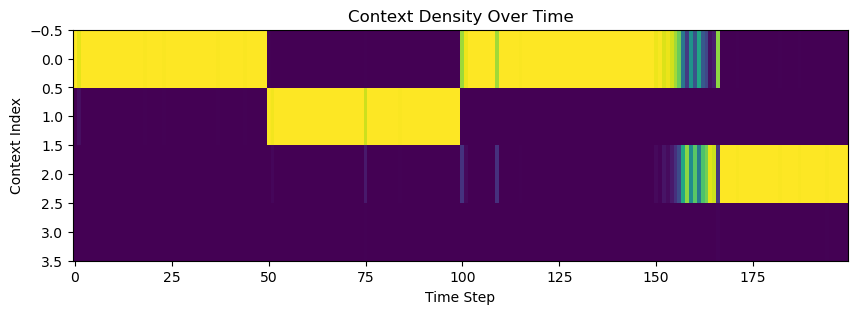

Actions History:


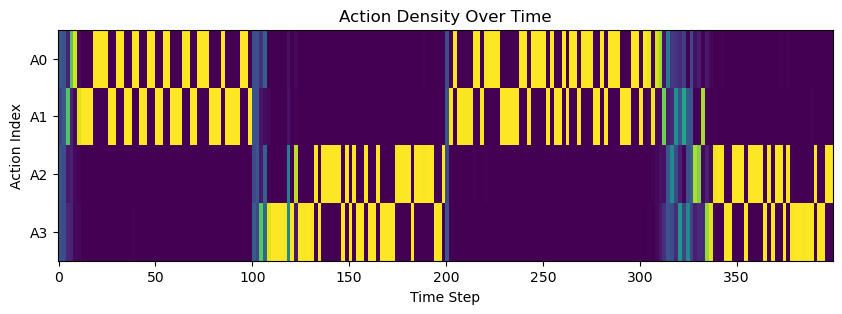

Proportion of Optimal Actions Over Time:


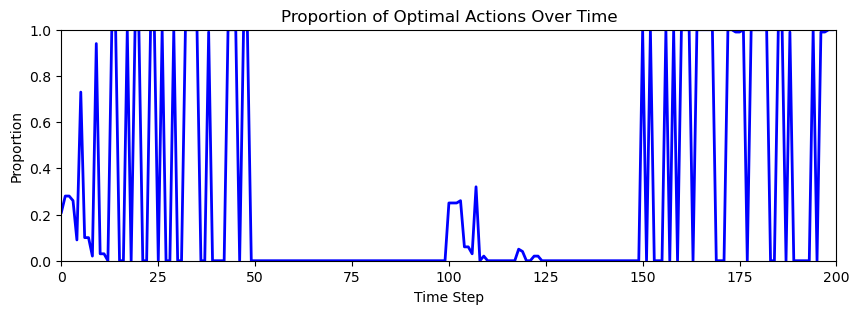

Jump History:


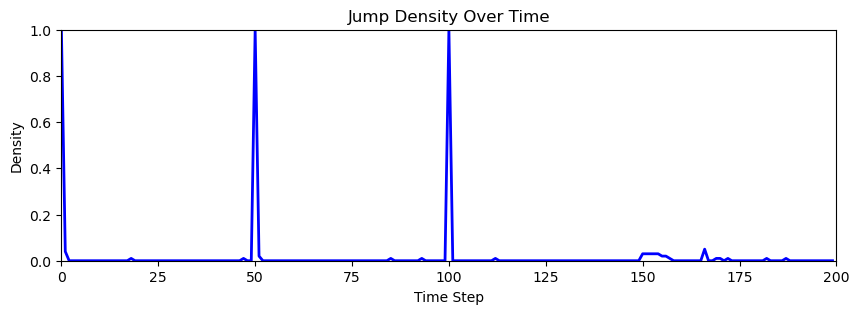

Inferred S History:


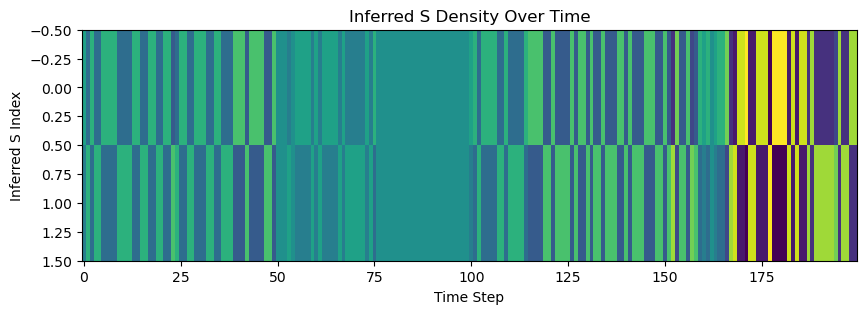

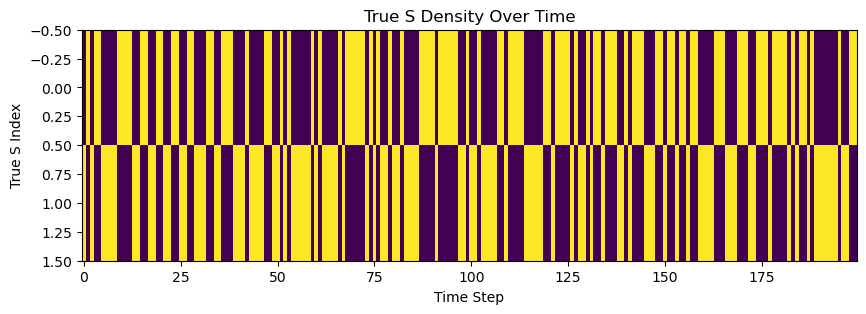

In [10]:
jump_times = []
j = 0
context_o_hist_arr = np.array(results[j].subject_history.context_o)
context_r_hist_arr = np.array(results[j].subject_history.context_r)
p_actions_arr = np.array(results[j].subject_history.p_action)
p_jump_arr = np.array(results[j].subject_history.p_jump)
p_state_arr = np.array(results[j].subject_history.p_state)
weight_arr = np.array(results[j].subject_history.weights)
p_action_optimal = results[j].p_optimal_action

print("Context History:")
max_context_o = np.max(context_o_hist_arr) + 1
context_o_densities = np.zeros((len(context_o_hist_arr), max_context_o))
for t, element in enumerate(context_o_hist_arr):
    for particle_id, val in enumerate(element):
        context_o_densities[t, val] += weight_arr[t][particle_id]
context_o_densities = context_o_densities / context_o_densities.sum(
    axis=1, keepdims=True
)

# set size of plot
plt.figure(figsize=(10, 3))
plt.imshow(
    context_o_densities.T, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)


plt.xlabel("Time Step")
plt.ylabel("Context Index")
plt.title("Context Density Over Time")
# plt.savefig("g_context_o_density.pdf")
plt.show()


print("Actions History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_actions_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
plt.yticks(ticks=[0, 1, 2, 3], labels=["A0", "A1", "A2", "A3"])
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Action Index")
plt.title("Action Density Over Time")
# plt.savefig("g_action_density.pdf")
plt.show()

print("Proportion of Optimal Actions Over Time:")

plt.figure(figsize=(10, 3))
plt.plot(p_action_optimal, label="Proportion Optimal Action", color="blue", linewidth=2)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.xlim(0, len(p_action_optimal))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_proportion_optimal.pdf")
plt.show()

print("Jump History:")

plt.figure(figsize=(10, 3))
plt.plot(p_jump_arr, label="Jump", color="blue", linewidth=2)
plt.title("Jump Density Over Time")
plt.xlabel("Time Step")
plt.ylabel("Density")
plt.ylim(0, 1)
plt.xlim(0, len(p_jump_arr))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_jump_density.pdf")
plt.show()

print("Inferred S History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_state_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Inferred S Index")
plt.title("Inferred S Density Over Time")
# plt.savefig("g_inferred_s_density.pdf")
plt.show()


true_s_hist_arr = np.asarray(results[j].experiment_history.state)

plt.figure(figsize=(10, 3))
true_s_densities = np.zeros((len(true_s_hist_arr), 2))
for idx, val in enumerate(true_s_hist_arr):
    true_s_densities[idx, val] += 1
true_s_densities = true_s_densities / true_s_densities.sum(axis=1, keepdims=True)
plt.imshow(true_s_densities.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("True S Index")
plt.title("True S Density Over Time")
# plt.savefig("g_true_s_density.pdf")
plt.show()